# Model Comparison — XGBoost vs MLP vs DNN vs GNN vs PNN, both channels

Consolidated comparison of the five model families (XGBoost, MLP, DNN, GNN,
PNN) across both channels (1l2tau, 2l2tau) and all three tracks (Run 2,
Run 3, Combined) — except GNN, which currently only has a 1l2tau notebook
(`GNN_Evie.ipynb`), and PNN, which currently only has a 1l2tau Run 2 track
(`PNN.ipynb`); missing channel/track cells will simply show "no data" until
those counterparts exist.

**This is a scaffold, not a fresh analysis** - it does not retrain or reload
any model. It simply reads the small standardized `model_summary_<model>.csv`
files that each pipeline notebook exports at the end of its run
(`Final_Notebooks/1L2Tau_Master_Pipeline.ipynb`, `2L2Tau_Master_Pipeline.ipynb`,
`MLP.ipynb`, `MLP_2l2tau.ipynb`, `DNN.ipynb`, `DNN_2l2tau.ipynb`,
`GNN_Evie.ipynb`, `PNN.ipynb`), each writing to
`PPSSP_2026/<channel>/summary_plots/model_summary_<model>.csv`.

**None of these pipeline notebooks have been executed yet as of writing**,
so running this notebook cold will show "no data found" for every channel -
that's expected. Run (or re-run) any of the notebooks first, then re-run
this one; it picks up whichever summary files exist and simply notes which
model/channel combinations are still missing, rather than failing.


## 1. Load whatever summary CSVs exist

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

CHANNELS = ["1l2tau", "2l2tau"]
MODELS = ["xgboost", "mlp", "dnn", "gnn", "pnn"]

frames = []
missing = []
for channel in CHANNELS:
    for model in MODELS:
        path = Path(f"PPSSP_2026/{channel}/summary_plots/model_summary_{model}.csv")
        if path.exists():
            df = pd.read_csv(path)
            frames.append(df)
            print(f"Loaded {path} ({len(df)} rows)")
        else:
            missing.append(str(path))

if frames:
    all_summary = pd.concat(frames, ignore_index=True)
else:
    all_summary = pd.DataFrame(columns=["channel", "model", "track", "val_auc", "test_auc"])

if missing:
    print(f"\n{len(missing)} / {len(CHANNELS) * len(MODELS)} expected summary files not found yet "
          f"(run the corresponding pipeline notebook to produce them):")
    for m in missing:
        print(f"  - {m}")

all_summary


Loaded PPSSP_2026/1l2tau/summary_plots/model_summary_xgboost.csv (3 rows)
Loaded PPSSP_2026/1l2tau/summary_plots/model_summary_mlp.csv (3 rows)
Loaded PPSSP_2026/1l2tau/summary_plots/model_summary_dnn.csv (3 rows)
Loaded PPSSP_2026/1l2tau/summary_plots/model_summary_gnn.csv (3 rows)
Loaded PPSSP_2026/2l2tau/summary_plots/model_summary_xgboost.csv (3 rows)
Loaded PPSSP_2026/2l2tau/summary_plots/model_summary_mlp.csv (3 rows)
Loaded PPSSP_2026/2l2tau/summary_plots/model_summary_dnn.csv (3 rows)

1 / 8 expected summary files not found yet (run the corresponding pipeline notebook to produce them):
  - PPSSP_2026/2l2tau/summary_plots/model_summary_gnn.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,xgboost,Run 2,0.933726,0.937122
1,1l2tau,xgboost,Run 3,0.941192,0.943050
2,1l2tau,xgboost,Combined,0.939922,0.940152
3,1l2tau,mlp,Run 2,0.943178,0.948052
4,1l2tau,mlp,Run 3,0.949010,0.951494
5,1l2tau,mlp,Combined,0.949319,0.948768
6,1l2tau,dnn,Run 2,0.931278,0.934655
7,1l2tau,dnn,Run 3,0.939236,0.941017
8,1l2tau,dnn,Combined,0.938932,0.937224
9,1l2tau,gnn,Run 2,0.909983,0.916594


## 2. Per-channel comparison table

Held-out **test** AUC (scored exactly once per track, see each pipeline's
"Held-Out Test Evaluation" section) is the number to trust for comparing
models - it's the only one none of the three model families ever used for
model/feature/hyperparameter selection. Validation AUC is shown alongside
for reference, since it's what each notebook's own tuning targeted.


In [2]:
TRACK_ORDER = ["Run 2", "Run 3", "Combined"]

for channel in CHANNELS:
    sub = all_summary.loc[all_summary["channel"] == channel]
    if sub.empty:
        print(f"--- {channel}: no data yet ---\n")
        continue

    pivot_test = sub.pivot(index="model", columns="track", values="test_auc").reindex(columns=TRACK_ORDER)
    pivot_val = sub.pivot(index="model", columns="track", values="val_auc").reindex(columns=TRACK_ORDER)

    print(f"=== {channel} — held-out TEST AUC ===")
    print(pivot_test.to_string(float_format=lambda x: f"{x:.4f}" if pd.notna(x) else "  -   "))
    print(f"\n=== {channel} — VALIDATION AUC (reference only) ===")
    print(pivot_val.to_string(float_format=lambda x: f"{x:.4f}" if pd.notna(x) else "  -   "))
    print()


=== 1l2tau — held-out TEST AUC ===
track    Run 2  Run 3  Combined
model                          
dnn     0.9347 0.9410    0.9372
gnn     0.9166 0.9200    0.9228
mlp     0.9481 0.9515    0.9488
xgboost 0.9371 0.9430    0.9402

=== 1l2tau — VALIDATION AUC (reference only) ===
track    Run 2  Run 3  Combined
model                          
dnn     0.9313 0.9392    0.9389
gnn     0.9100 0.9208    0.9227
mlp     0.9432 0.9490    0.9493
xgboost 0.9337 0.9412    0.9399

=== 2l2tau — held-out TEST AUC ===
track    Run 2  Run 3  Combined
model                          
dnn     0.9721 0.9781    0.9773
mlp     0.9615 0.9706    0.9684
xgboost 0.9740 0.9735    0.9732

=== 2l2tau — VALIDATION AUC (reference only) ===
track    Run 2  Run 3  Combined
model                          
dnn     0.9748 0.9819    0.9788
mlp     0.9652 0.9740    0.9711
xgboost 0.9730 0.9774    0.9719



## 3. Grouped bar chart per channel (held-out test AUC)

Saved plot -> PPSSP_2026/model_comparison_plots/ModelComparison_1l2tau.png


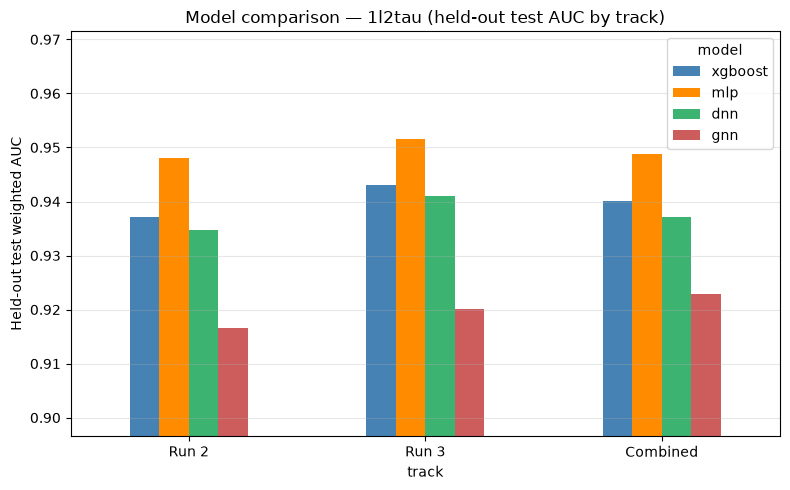

Saved plot -> PPSSP_2026/model_comparison_plots/ModelComparison_2l2tau.png


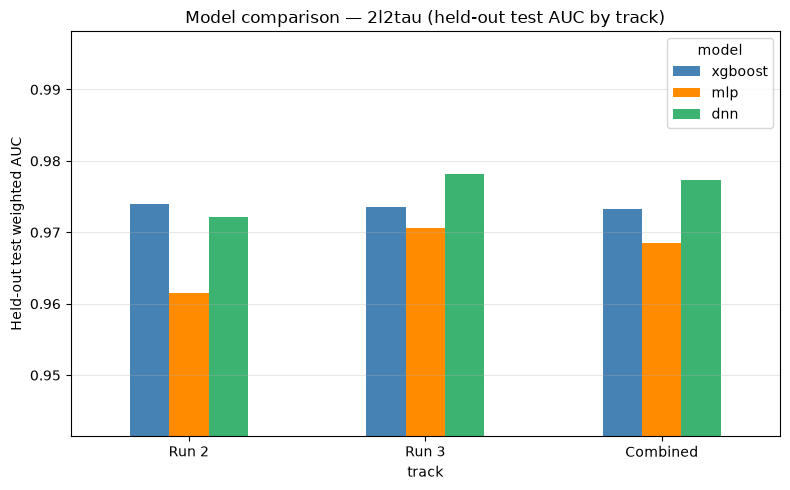

In [ ]:
PLOTS_DIR_COMPARISON = Path("PPSSP_2026/model_comparison_plots")
PLOTS_DIR_COMPARISON.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = {"xgboost": "steelblue", "mlp": "darkorange", "dnn": "mediumseagreen", "gnn": "indianred", "pnn": "mediumpurple"}

for channel in CHANNELS:
    sub = all_summary.loc[all_summary["channel"] == channel]
    if sub.empty:
        continue

    pivot_test = sub.pivot(index="model", columns="track", values="test_auc").reindex(columns=TRACK_ORDER)
    models_present = [m for m in MODELS if m in pivot_test.index]
    if not models_present:
        continue
    pivot_test = pivot_test.reindex(index=models_present)

    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_test.T.plot.bar(ax=ax, color=[MODEL_COLORS[m] for m in models_present], rot=0)
    ax.set_ylabel("Held-out test weighted AUC")
    ax.set_title(f"Model comparison — {channel} (held-out test AUC by track)")
    ax.grid(axis="y", alpha=0.3)
    valid_vals = pivot_test.to_numpy()
    valid_vals = valid_vals[~pd.isna(valid_vals)]
    if len(valid_vals):
        ax.set_ylim(max(0.5, valid_vals.min() - 0.02), valid_vals.max() + 0.02)
    plt.tight_layout()

    plot_path = PLOTS_DIR_COMPARISON / f"ModelComparison_{channel}.png"
    fig.savefig(plot_path, dpi=150)
    print(f"Saved plot -> {plot_path}")
    plt.show()


## 4. Domain-shift agreement check (sanity, not a model comparison)

Each pipeline also runs its own Run2-vs-Run3 domain-shift scan, but the
result is a property of the **input features**, not of the downstream model
- so the XGBoost/MLP/DNN versions should agree closely (same combined
tuned-feature list, same ROOT data, only the internal CV splits differ by
random draw). This is a consistency check on that assumption, not a "which
model wins" comparison.


In [4]:
DOMAIN_CSV_BY_CHANNEL = {
    "1l2tau": Path("run2_vs_run3_auc_summary.csv"),
    "2l2tau": Path("run2_vs_run3_auc_summary_2l2tau.csv"),
}

for channel, path in DOMAIN_CSV_BY_CHANNEL.items():
    if not path.exists():
        print(f"--- {channel}: {path} not found yet (run any pipeline notebook for this channel) ---\n")
        continue
    df = pd.read_csv(path)
    print(f"=== {channel} — domain-shift AUC by process (from {path}) ===")
    print(df[["process", "mean_auc", "std_auc"]].sort_values("mean_auc", ascending=False).to_string(index=False))
    print()


=== 1l2tau — domain-shift AUC by process (from run2_vs_run3_auc_summary.csv) ===
   process  mean_auc  std_auc
       VVV  0.572230 0.006668
   SingleH  0.570669 0.015419
     Zjets  0.559750 0.002087
     ttbar  0.543271 0.002146
     Wjets  0.541091 0.007733
   Diboson  0.534768 0.000858
signal_ggF  0.534492 0.002448
      tops  0.533789 0.007871
    Vgamma  0.513035 0.013988
signal_VBF  0.510253 0.001421

=== 2l2tau — domain-shift AUC by process (from run2_vs_run3_auc_summary_2l2tau.csv) ===
   process  mean_auc  std_auc
   SingleH  0.655005 0.010091
       VVV  0.614096 0.023241
    Vgamma  0.548779 0.017642
     Zjets  0.546400 0.019752
   Diboson  0.544471 0.002976
      tops  0.543736 0.032276
signal_ggF  0.516683 0.001791
     ttbar  0.506666 0.011649
signal_VBF  0.490016 0.002858
     Wjets  0.372678 0.100367

